# Deney Kıyaslama Notebook'u
**Proje:** TID — Türk İşaret Dili Tanıma  
**Veri Seti:** ErenDataset (AUTSL, 30 sınıf)  
**Amaç:** `ErenDataset/experiments/` altındaki tüm deneyleri kapsamlı biçimde karşılaştırmak.

### İçindekiler
1. Kurulum & Drive Bağlantısı
2. Deney Klasörlerini Tara
3. Config Karşılaştırması
4. Test Metrikleri Genel Tablo
5. Train vs Val Eğri Grafikleri
6. Sınıf Bazlı Performans (per-class F1)
7. Confusion Matrix Karşılaştırması
8. En İyi Deney Özeti


## 1. Kurulum & Drive Bağlantısı

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
import os, json, glob, yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from IPython.display import display

# ── Stil ──
plt.rcParams.update({
    'figure.dpi'      : 120,
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'font.size'       : 11,
})
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)

DRIVE_ROOT  = '/content/drive/MyDrive/Nöron-Ağları-Proje'
DATASET_ROOT = f'{DRIVE_ROOT}/ErenDataset'
EXP_ROOT    = f'{DATASET_ROOT}/experiments'

print(f'Experiments dizini: {EXP_ROOT}')


Experiments dizini: /content/drive/MyDrive/Nöron-Ağları-Proje/ErenDataset/experiments


## 2. Deney Klasörlerini Tara

In [19]:
def load_experiment(exp_dir):
    """Bir deney klasöründeki tüm dosyaları yükler."""
    exp = {'name': os.path.basename(exp_dir), 'path': exp_dir}

    # config.yaml
    cfg_path = os.path.join(exp_dir, 'config.yaml')
    exp['config'] = yaml.safe_load(open(cfg_path)) if os.path.exists(cfg_path) else {}

    # train_metrics.json
    tr_path = os.path.join(exp_dir, 'train_metrics.json')
    exp['train_metrics'] = json.load(open(tr_path)) if os.path.exists(tr_path) else []

    # test_metrics.json — metrikler 'general' anahtarı altında
    te_path = os.path.join(exp_dir, 'test_metrics.json')
    if os.path.exists(te_path):
        raw = json.load(open(te_path))
        exp['test_metrics'] = raw.get('general', raw)   # <-- düzeltme
        exp['per_class_raw'] = raw.get('per_class', {})
        exp['confusion_matrix_raw'] = raw.get('confusion_matrix', None)
    else:
        exp['test_metrics'] = {}
        exp['per_class_raw'] = {}
        exp['confusion_matrix_raw'] = None

    # confusion matrix resmi
    cm_path = os.path.join(exp_dir, 'confusion_matrix.png')
    exp['cm_path'] = cm_path if os.path.exists(cm_path) else None

    return exp

In [20]:
# Tüm deney klasörlerini bul ve yükle
exp_dirs = sorted(glob.glob(os.path.join(EXP_ROOT, '*')))
exp_dirs = [d for d in exp_dirs if os.path.isdir(d)]

experiments = [load_experiment(d) for d in exp_dirs]

print(f'Toplam deney sayısı: {len(experiments)}')
print()
for i, exp in enumerate(experiments):
    te = exp['test_metrics']
    acc = te.get('accuracy', te.get('test_accuracy', '?'))
    f1  = te.get('macro_f1',  te.get('f1', '?'))
    if isinstance(acc, float): acc = f'{acc:.4f}'
    if isinstance(f1,  float): f1  = f'{f1:.4f}'
    print(f'  [{i:2d}] {exp["name"]}  |  acc={acc}  f1={f1}')


Toplam deney sayısı: 12

  [ 0] 2026-05-23_02-20-59  |  acc=0.8907  f1=0.8870
  [ 1] 2026-05-23_02-40-31  |  acc=0.9292  f1=0.9284
  [ 2] 2026-05-23_02-55-15  |  acc=0.9211  f1=0.9200
  [ 3] 2026-05-23_19-34-32  |  acc=0.8684  f1=0.8636
  [ 4] 2026-05-23_19-40-26  |  acc=0.8725  f1=0.8630
  [ 5] 2026-05-23_19-53-14  |  acc=0.9372  f1=0.9359
  [ 6] 2026-05-23_21-31-05  |  acc=0.9231  f1=0.9220
  [ 7] 2026-05-23_21-41-00  |  acc=0.9170  f1=0.9138
  [ 8] 2026-05-23_21-50-23  |  acc=0.9109  f1=0.9095
  [ 9] 2026-05-23_21-56-55  |  acc=0.8927  f1=0.8891
  [10] 2026-05-23_23-00-50  |  acc=0.8725  f1=0.8698
  [11] 2026-05-26_21-17-44  |  acc=0.9271  f1=0.9254


In [21]:
def count_params(cfg):
    """Config'den model parametre sayısını tahmin eder."""
    m = cfg.get('model', {})
    lstm_units  = m.get('lstm_units', [256, 128])
    dense_units = m.get('dense_units', 128)
    num_features = cfg.get('data', {}).get('num_features', 170)
    num_classes  = cfg.get('data', {}).get('num_classes', 30)

    # Dense projeksiyon (num_features → 128)
    proj_out = 128
    p  = num_features * proj_out + proj_out

    # BiLSTM 1
    lu0 = lstm_units[0]
    p += 2 * (4 * ((proj_out + lu0) * lu0 + lu0))
    p += 4 * (lu0 * 2)   # BatchNorm

    # BiLSTM 2
    lu1 = lstm_units[1]
    p += 2 * (4 * ((lu0 * 2 + lu1) * lu1 + lu1))
    p += 4 * (lu1 * 2)   # BatchNorm

    # MaskedAttention
    p += (lu1 * 2) * 1 + 1

    # Dense(dense_units) + BatchNorm
    p += (lu1 * 2) * dense_units + dense_units
    p += 4 * dense_units

    # Dense(num_classes)
    p += dense_units * num_classes + num_classes

    return p

In [22]:
summary = []
for exp in experiments:
    name = exp['name'][11:]
    te   = exp['test_metrics']
    tm   = exp['train_metrics']

    test_acc = te.get('accuracy', np.nan)
    test_f1  = te.get('macro_f1', np.nan)

    if tm:
        val_accs   = [e.get('val', {}).get('accuracy', 0) for e in tm]
        best_i     = int(np.argmax(val_accs))
        train_acc  = tm[best_i].get('train', {}).get('accuracy', np.nan)
        train_f1   = tm[best_i].get('train', {}).get('macro_f1', np.nan)
        train_loss = tm[best_i].get('train', {}).get('loss', np.nan)
        val_loss   = tm[best_i].get('val',   {}).get('loss', np.nan)
        total_ep   = len(tm)
        best_ep    = tm[best_i].get('epoch', best_i + 1)
    else:
        train_acc = train_f1 = train_loss = val_loss = np.nan
        total_ep = best_ep = '?'

    overfit_acc = train_acc - test_acc
    overfit_f1  = train_f1  - test_f1
    loss_gap    = val_loss - train_loss if not np.isnan(train_loss) else np.nan
    n_params    = count_params(exp['config'])

    summary.append({
        'name':        name,
        'test_acc':    test_acc,
        'test_f1':     test_f1,
        'train_loss':  train_loss,
        'val_loss':    val_loss,
        'loss_gap':    loss_gap,
        'overfit_acc': overfit_acc,
        'overfit_f1':  overfit_f1,
        'best_ep':     best_ep,
        'total_ep':    total_ep,
        'n_params':    n_params,
    })

In [23]:
cols = [
    ('deney',      12),
    ('test_acc',   10),
    ('test_f1',    10),
    ('tr_loss',    10),
    ('val_loss',   10),
    ('loss_gap',   10),
    ('Δacc',       10),
    ('ΔF1',        10),
    ('ep',          8),
    ('params',     12),
    ('flag',        6),
]

def c(val, width):
    return str(val).center(width)

header = ''.join(c(name, w) for name, w in cols)
print(header)
print('─' * sum(w for _, w in cols))

for r in summary:
    flag      = '⚠' if r['overfit_acc'] > 0.05 else '-'
    ep_str    = f"{r['best_ep']}/{r['total_ep']}"
    param_str = f"{r['n_params']:,}"

    vals = [
        r['name'],
        f"{r['test_acc']:.4f}",
        f"{r['test_f1']:.4f}",
        f"{r['train_loss']:.4f}",
        f"{r['val_loss']:.4f}",
        f"{r['loss_gap']:.4f}",
        f"{r['overfit_acc']:.4f}",
        f"{r['overfit_f1']:.4f}",
        ep_str,
        param_str,
        flag,
    ]
    print(''.join(c(v, w) for v, (_, w) in zip(vals, cols)))

print()
print('  Δacc / ΔF1  = train − test')
print('  loss_gap    = val_loss − train_loss')
print('  flag        = ⚠ → Δacc > 0.05  |  - → Δacc < 0.05')

   deney     test_acc  test_f1   tr_loss   val_loss  loss_gap    Δacc      ΔF1       ep      params    flag 
────────────────────────────────────────────────────────────────────────────────────────────────────────────
  02-20-59    0.8907    0.8870    0.0248    0.4332    0.4084    0.1042    0.1099   23/38   1,507,359    ⚠   
  02-40-31    0.9292    0.9284    0.5402    0.8470    0.3068    0.0595    0.0647   31/46   1,507,359    ⚠   
  02-55-15    0.9211    0.9200    0.3738    0.6960    0.3222    0.0760    0.0797   37/47    461,535     ⚠   
  19-34-32    0.8684    0.8636    1.0710    1.1835    0.1125    0.0455    0.0867   15/25   1,507,359    -   
  19-40-26    0.8725    0.8630    1.0625    1.1732    0.1107    0.0301    0.0785   11/21    461,535     -   
  19-53-14    0.9372    0.9359    1.0977    1.1645    0.0668    0.0490    0.0604   41/51   1,507,359    -   
  21-31-05    0.9231    0.9220    1.3150    1.4392    0.1243    0.0769    0.0780   83/100  1,507,359    ⚠   
  21-41-00    0.917

## 3. Config Karşılaştırması
Her deneyin hyperparameter'larını yan yana gösteren tablo.


In [24]:
# Config karşılaştırması için yardımcı fonksiyon
def flatten_config(cfg, prefix=''):
    items = {}
    for k, v in cfg.items():
        full_key = f'{prefix}.{k}' if prefix else k
        if isinstance(v, dict):
            items.update(flatten_config(v, full_key))
        else:
            items[full_key] = v
    return items

# Göstermek istemediğimiz sütunlar
EXCLUDE_COLS = {
    'experiment.name', 'experiment.notes',
    'data.train_path', 'data.val_path', 'data.test_path',
}

rows = {}
for exp in experiments:
    flat = flatten_config(exp['config'])
    filtered = {k: v for k, v in flat.items() if k not in EXCLUDE_COLS}
    rows[exp['name']] = filtered

df_config = pd.DataFrame(rows).T

# Deneylere göre değişen vs sabit sütunları ayır
varying_cols  = [c for c in df_config.columns if df_config[c].astype(str).nunique(dropna=False) > 1]
constant_cols = [c for c in df_config.columns if c not in varying_cols]

print(f'Değişen parametre sayısı : {len(varying_cols)}')
print(f'Sabit parametre sayısı   : {len(constant_cols)}')

Değişen parametre sayısı : 19
Sabit parametre sayısı   : 11


In [25]:
# Değişen parametreler — sütun/satır isimlerini kısalt
df_vary = df_config[varying_cols].copy()

df_vary.columns = [
    c.replace('model.', '').replace('training.', '').replace('augmentation.', 'aug.')
    for c in df_vary.columns
]
df_vary.index = [n[11:] for n in df_vary.index]  # sadece HH-MM-SS

display(df_vary.style
        .set_caption('Deneyler Arası Değişen Parametreler')
        .highlight_null(color='#eeeeee')
        .format(lambda x: '—' if str(x) in ('nan', 'None', '') else str(x)))

,dense_units,dropout,lstm_units,batch_size,early_stopping_patience,l2,aug.enabled,aug.gaussian_noise.enabled,aug.gaussian_noise.std,aug.spatial_scaling.enabled,aug.spatial_scaling.max,aug.spatial_scaling.min,aug.temporal_scaling.enabled,aug.temporal_scaling.max,aug.temporal_scaling.min,label_smoothing,recurrent_dropout,aug.mixup.alpha,aug.mixup.enabled
02-20-59,128,0.4,"[256, 128]",32,15,—,—,—,—,—,—,—,—,—,—,—,—,—,—
02-40-31,128,0.5,"[256, 128]",32,15,0.001,—,—,—,—,—,—,—,—,—,—,—,—,—
02-55-15,64,0.5,"[128, 64]",32,10,0.001,—,—,—,—,—,—,—,—,—,—,—,—,—
19-34-32,128,0.5,"[256, 128]",32,10,0.001,True,True,0.005,True,1.1,0.9,True,1.1,0.9,—,—,—,—
19-40-26,64,0.5,"[128, 64]",32,10,0.001,True,True,0.005,True,1.1,0.9,True,1.1,0.9,—,—,—,—
19-53-14,128,0.5,"[256, 128]",32,10,0.001,False,False,0.005,False,1.1,0.9,False,1.1,0.9,0.1,—,—,—
21-31-05,128,0.5,"[256, 128]",32,10,0.001,False,False,0.005,False,1.1,0.9,False,1.1,0.9,0.2,—,—,—
21-41-00,128,0.5,"[256, 128]",32,10,0.001,False,False,0.005,False,1.1,0.9,False,1.1,0.9,0.2,—,—,—
21-50-23,64,0.5,"[128, 64]",32,10,0.001,False,False,0.005,False,1.1,0.9,False,1.1,0.9,0.1,—,—,—
21-56-55,128,0.5,"[256, 128]",32,10,0.001,False,False,0.005,False,1.1,0.9,False,1.1,0.9,0.1,0.2,—,—


In [26]:
SHORT_NAMES = {
    'model.lstm_units':                      'lstm_units',
    'model.dense_units':                     'dense_units',
    'model.dropout':                         'dropout',
    'model.l2':                              'l2',
    'model.recurrent_dropout':               'rec_dropout',
    'training.batch_size':                   'batch_size',
    'training.label_smoothing':              'label_smooth',
    'training.early_stopping_patience':      'es_patience',
    'augmentation.enabled':                  'aug',
    'augmentation.gaussian_noise.enabled':   'aug.noise',
    'augmentation.temporal_scaling.enabled': 'aug.temporal',
    'augmentation.spatial_scaling.enabled':  'aug.spatial',
    'augmentation.mixup.enabled':            'mixup',
    'augmentation.mixup.alpha':              'mixup.alpha',
}

SHOW_COLS = list(SHORT_NAMES.keys())

def format_val(val):
    if val is None or str(val) == 'nan':
        return '-'
    elif isinstance(val, bool):
        return 'yes' if val else 'no'
    elif isinstance(val, float):
        return f'{val:.3f}'
    elif isinstance(val, list):
        return str(val).replace(' ', '')
    return str(val)

def ctr(val, width):
    return str(val).center(width)

# Sütun genişliklerini içeriğe göre otomatik belirle
all_flats = [flatten_config(exp['config']) for exp in experiments]

col_widths = []
for col in SHOW_COLS:
    name     = SHORT_NAMES[col]
    max_data = max(len(format_val(flat.get(col, None))) for flat in all_flats)
    col_widths.append(max(len(name), max_data) + 3)

label_w = 12

# Başlık
header = ctr('deney', label_w) + ''.join(ctr(SHORT_NAMES[col], w) for col, w in zip(SHOW_COLS, col_widths))
sep    = '─' * (label_w + sum(col_widths))
print(header)
print(sep)

# Satırlar
for exp, flat in zip(experiments, all_flats):
    label = exp['name'][11:]
    row   = ctr(label, label_w)
    for col, w in zip(SHOW_COLS, col_widths):
        row += ctr(format_val(flat.get(col, None)), w)
    print(row)

print()
print('Test Accuracy referansı:')
print(sep)
for exp in experiments:
    acc = exp['test_metrics'].get('accuracy', float('nan'))
    print(ctr(exp['name'][11:], label_w) + ctr(f'{acc:.4f}', 12))

   deney      lstm_units  dense_units   dropout     l2    rec_dropout    batch_size   label_smooth  es_patience   aug   aug.noise    aug.temporal  aug.spatial   mixup   mixup.alpha  
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  02-20-59    [256,128]       128        0.400      -          -             32            -             15        -        -             -             -          -          -       
  02-40-31    [256,128]       128        0.500    0.001        -             32            -             15        -        -             -             -          -          -       
  02-55-15     [128,64]        64        0.500    0.001        -             32            -             10        -        -             -             -          -          -       
  19-34-32    [256,128]       128        0.500    0.001        -             32      

In [27]:
# Sabit parametreler — tek satır göster
if constant_cols:
    df_const = df_config[constant_cols].iloc[:1].T
    df_const.columns = ['Değer']
    df_const.index = [
        i.replace('model.', '').replace('training.', '').replace('augmentation.', 'aug.')
        for i in df_const.index
    ]
    print('Tüm deneylerde sabit olan parametreler:')
    display(df_const)

Tüm deneylerde sabit olan parametreler:


,Değer
data.max_seq_len,82
data.num_classes,30
data.num_features,170
data.padding_value,-1.0000
bidirectional,True
type,BiLSTM_Attention
epochs,100
learning_rate,0.0010
min_lr,0.0000
reduce_lr_factor,0.5000


## 4. Test Metrikleri — Genel Tablo
Accuracy, Macro F1, Precision, Recall ve Top-5 Accuracy.


In [28]:
def extract_test_metrics(exp):
    te  = exp['test_metrics']
    row = {'experiment': exp['name']}
    for key, aliases in [
        ('accuracy',    ['accuracy']),
        ('macro_f1',    ['macro_f1']),
        ('macro_p',     ['macro_precision']),
        ('macro_r',     ['macro_recall']),
        ('top5_acc',    ['top5_accuracy']),
        ('test_time_s', ['test_time_sec', 'test_time_s']),
        ('num_samples', ['num_samples']),
    ]:
        for alias in aliases:
            if alias in te:
                row[key] = te[alias]
                break
        else:
            row[key] = None
    return row

df_test = pd.DataFrame([extract_test_metrics(e) for e in experiments])
df_test = df_test.set_index('experiment')

# Satır isimlerini kısalt
df_test.index = [n[11:] for n in df_test.index]

numeric_cols = df_test.select_dtypes(include='number').columns

display(df_test[numeric_cols].style
        .highlight_max(axis=0, color='#2d5a2d', subset=numeric_cols)
        .highlight_min(axis=0, color='#5a2d2d', subset=numeric_cols)
        .set_caption('Test Metrikleri')
        .format('{:.4f}', na_rep='-')
        .set_table_styles([
            {'selector': 'caption', 'props': [('font-size', '13px'), ('font-weight', 'bold'), ('padding-bottom', '6px'), ('color', '#cccccc')]},
            {'selector': 'th',      'props': [('font-size', '11px'), ('padding', '4px 10px'), ('color', '#cccccc')]},
            {'selector': 'td',      'props': [('font-size', '11px'), ('padding', '4px 10px'), ('text-align', 'right'), ('color', '#dddddd')]},
            {'selector': 'tr:hover td', 'props': [('background-color', '#2a2a2a')]},
        ]))

,accuracy,macro_f1,macro_p,macro_r,top5_acc,test_time_s,num_samples
02-20-59,0.8907,0.8870,0.8945,0.8892,0.9919,0.2500,494.0000
02-40-31,0.9292,0.9284,0.9382,0.9292,1.0000,0.2300,494.0000
02-55-15,0.9211,0.9200,0.9323,0.9209,0.9980,0.2500,494.0000
19-34-32,0.8684,0.8636,0.8893,0.8655,0.9980,0.2300,494.0000
19-40-26,0.8725,0.8630,0.8840,0.8681,0.9838,0.2500,494.0000
19-53-14,0.9372,0.9359,0.9439,0.9376,0.9919,0.2300,494.0000
21-31-05,0.9231,0.9220,0.9301,0.9234,0.9939,0.2300,494.0000
21-41-00,0.9170,0.9138,0.9295,0.9169,0.9838,0.2200,494.0000
21-50-23,0.9109,0.9095,0.9271,0.9108,0.9939,0.2300,494.0000
21-56-55,0.8927,0.8891,0.9111,0.8920,0.9939,2.4700,494.0000


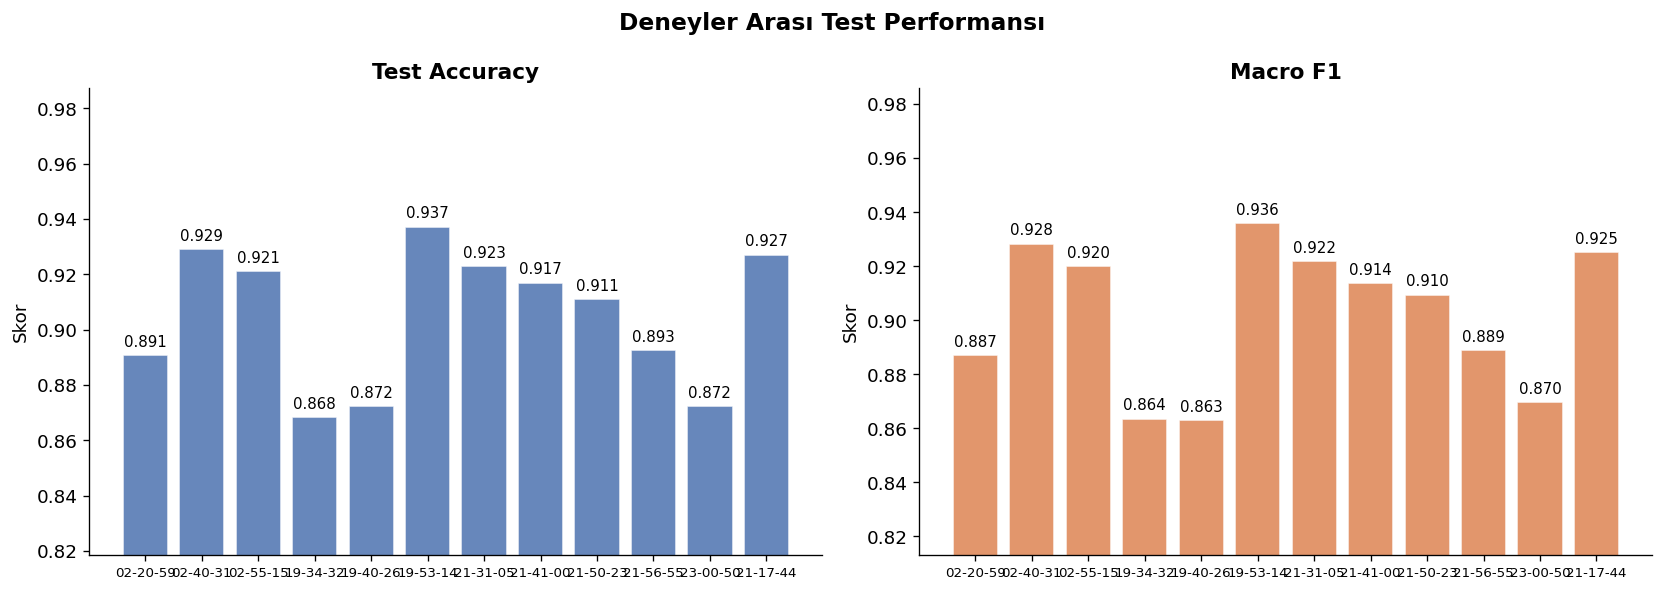

In [29]:
# Bar chart — Test Accuracy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names = [n.replace('_', '\n') for n in df_test.index]

for ax, col, title, color in [
    (axes[0], 'accuracy', 'Test Accuracy', '#4C72B0'),
    (axes[1], 'macro_f1', 'Macro F1',      '#DD8452'),
]:
    vals = df_test[col].fillna(0)
    bars = ax.bar(names, vals, color=color, alpha=0.85, edgecolor='white')
    ax.set_ylim(max(0, vals.min() - 0.05), min(1.0, vals.max() + 0.05))
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Skor')
    ax.tick_params(axis='x', labelsize=8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Deneyler Arası Test Performansı', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Train vs Val, Test
Her deney için Accuracy ve Loss eğrileri. `train_metrics.json` içindeki epoch bazlı verilerden çizilir.


In [30]:
def parse_train_metrics(train_metrics):
    """train_metrics.json → epoch, train_acc, val_acc, train_loss, val_loss listeleri"""
    epochs, tr_acc, vl_acc, tr_loss, vl_loss = [], [], [], [], []
    for e in train_metrics:
        epochs.append(e.get('epoch', len(epochs)+1))
        t = e.get('train', {})
        v = e.get('val',   {})
        tr_acc.append(t.get('accuracy',  t.get('acc', None)))
        vl_acc.append(v.get('accuracy',  v.get('acc', None)))
        tr_loss.append(t.get('loss', None))
        vl_loss.append(v.get('loss', None))
    return epochs, tr_acc, vl_acc, tr_loss, vl_loss


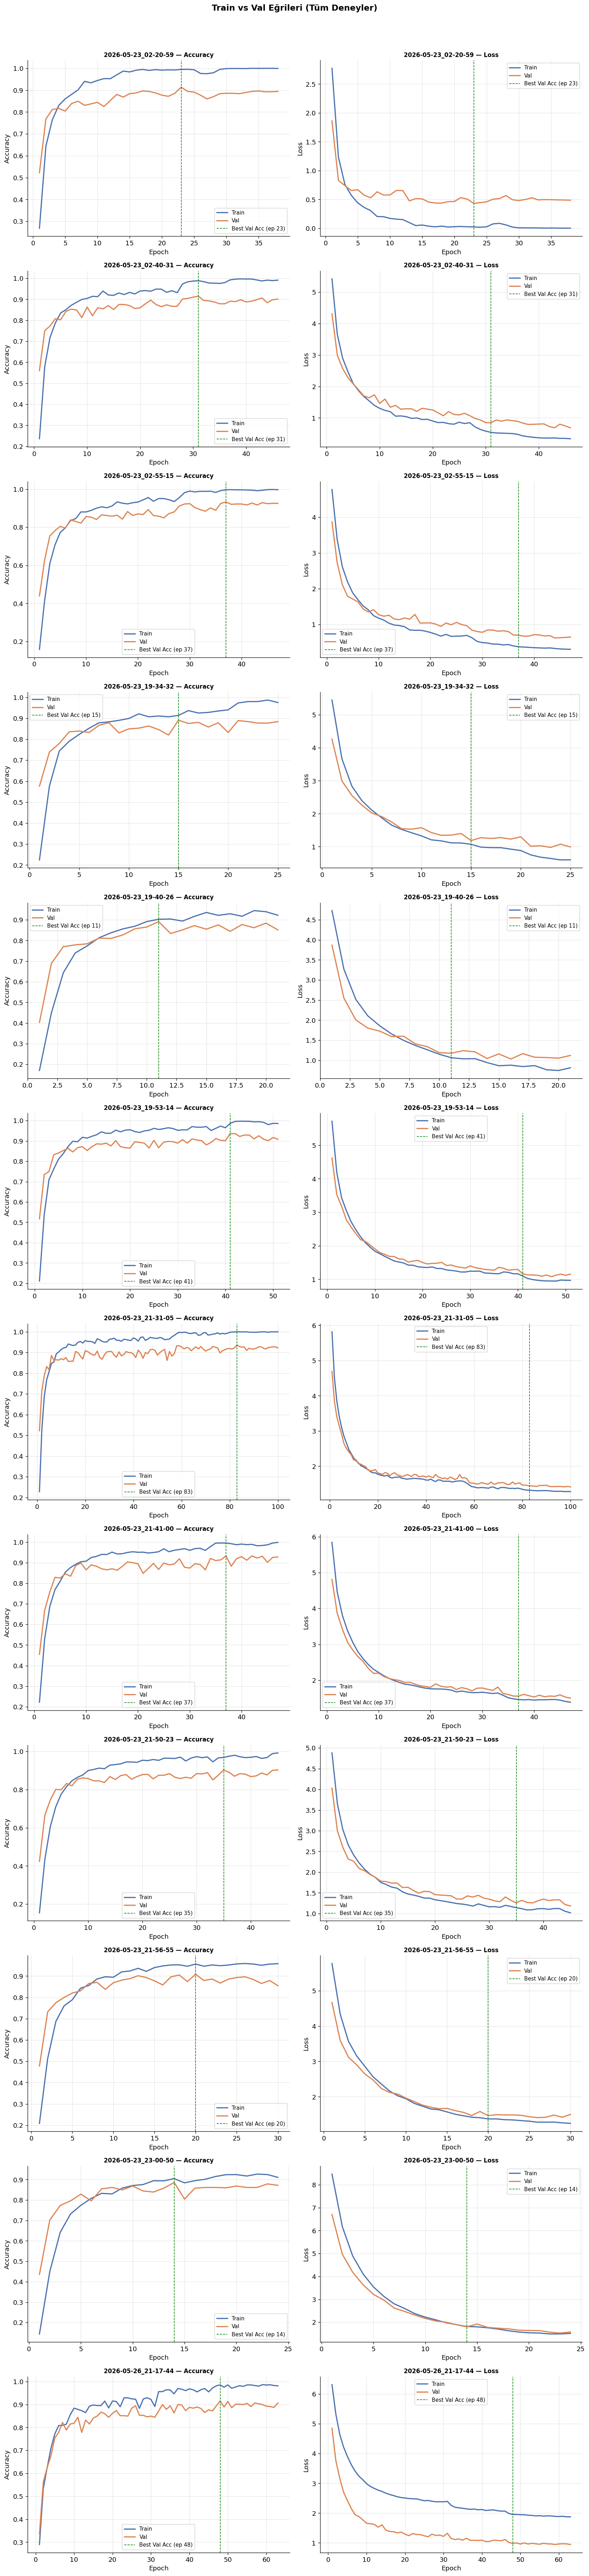

In [31]:
n_exp = len(experiments)
fig, axes = plt.subplots(n_exp, 2, figsize=(14, 5 * n_exp), squeeze=False)

for row_i, exp in enumerate(experiments):
    tm = exp['train_metrics']
    if not tm:
        axes[row_i, 0].set_visible(False)
        axes[row_i, 1].set_visible(False)
        continue

    epochs, tr_acc, vl_acc, tr_loss, vl_loss = parse_train_metrics(tm)

    best_val_acc_epoch = int(np.argmax([v if v is not None else 0 for v in vl_acc]))

    for col_i, (tr_vals, vl_vals, ylabel, title_sfx) in enumerate([
        (tr_acc,  vl_acc,  'Accuracy', 'Accuracy'),
        (tr_loss, vl_loss, 'Loss',     'Loss'),
    ]):
        ax = axes[row_i, col_i]
        ax.plot(epochs, tr_vals, label='Train', linewidth=2, color='#4C72B0')
        ax.plot(epochs, vl_vals, label='Val',   linewidth=2, color='#DD8452')
        ax.axvline(epochs[best_val_acc_epoch], color='green',
                   linestyle='--', linewidth=1, label=f'Best Val Acc (ep {epochs[best_val_acc_epoch]})')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)
        short_name = exp['name']
        ax.set_title(f'{short_name} — {title_sfx}', fontsize=10, fontweight='bold')

plt.suptitle('Train vs Val Eğrileri (Tüm Deneyler)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


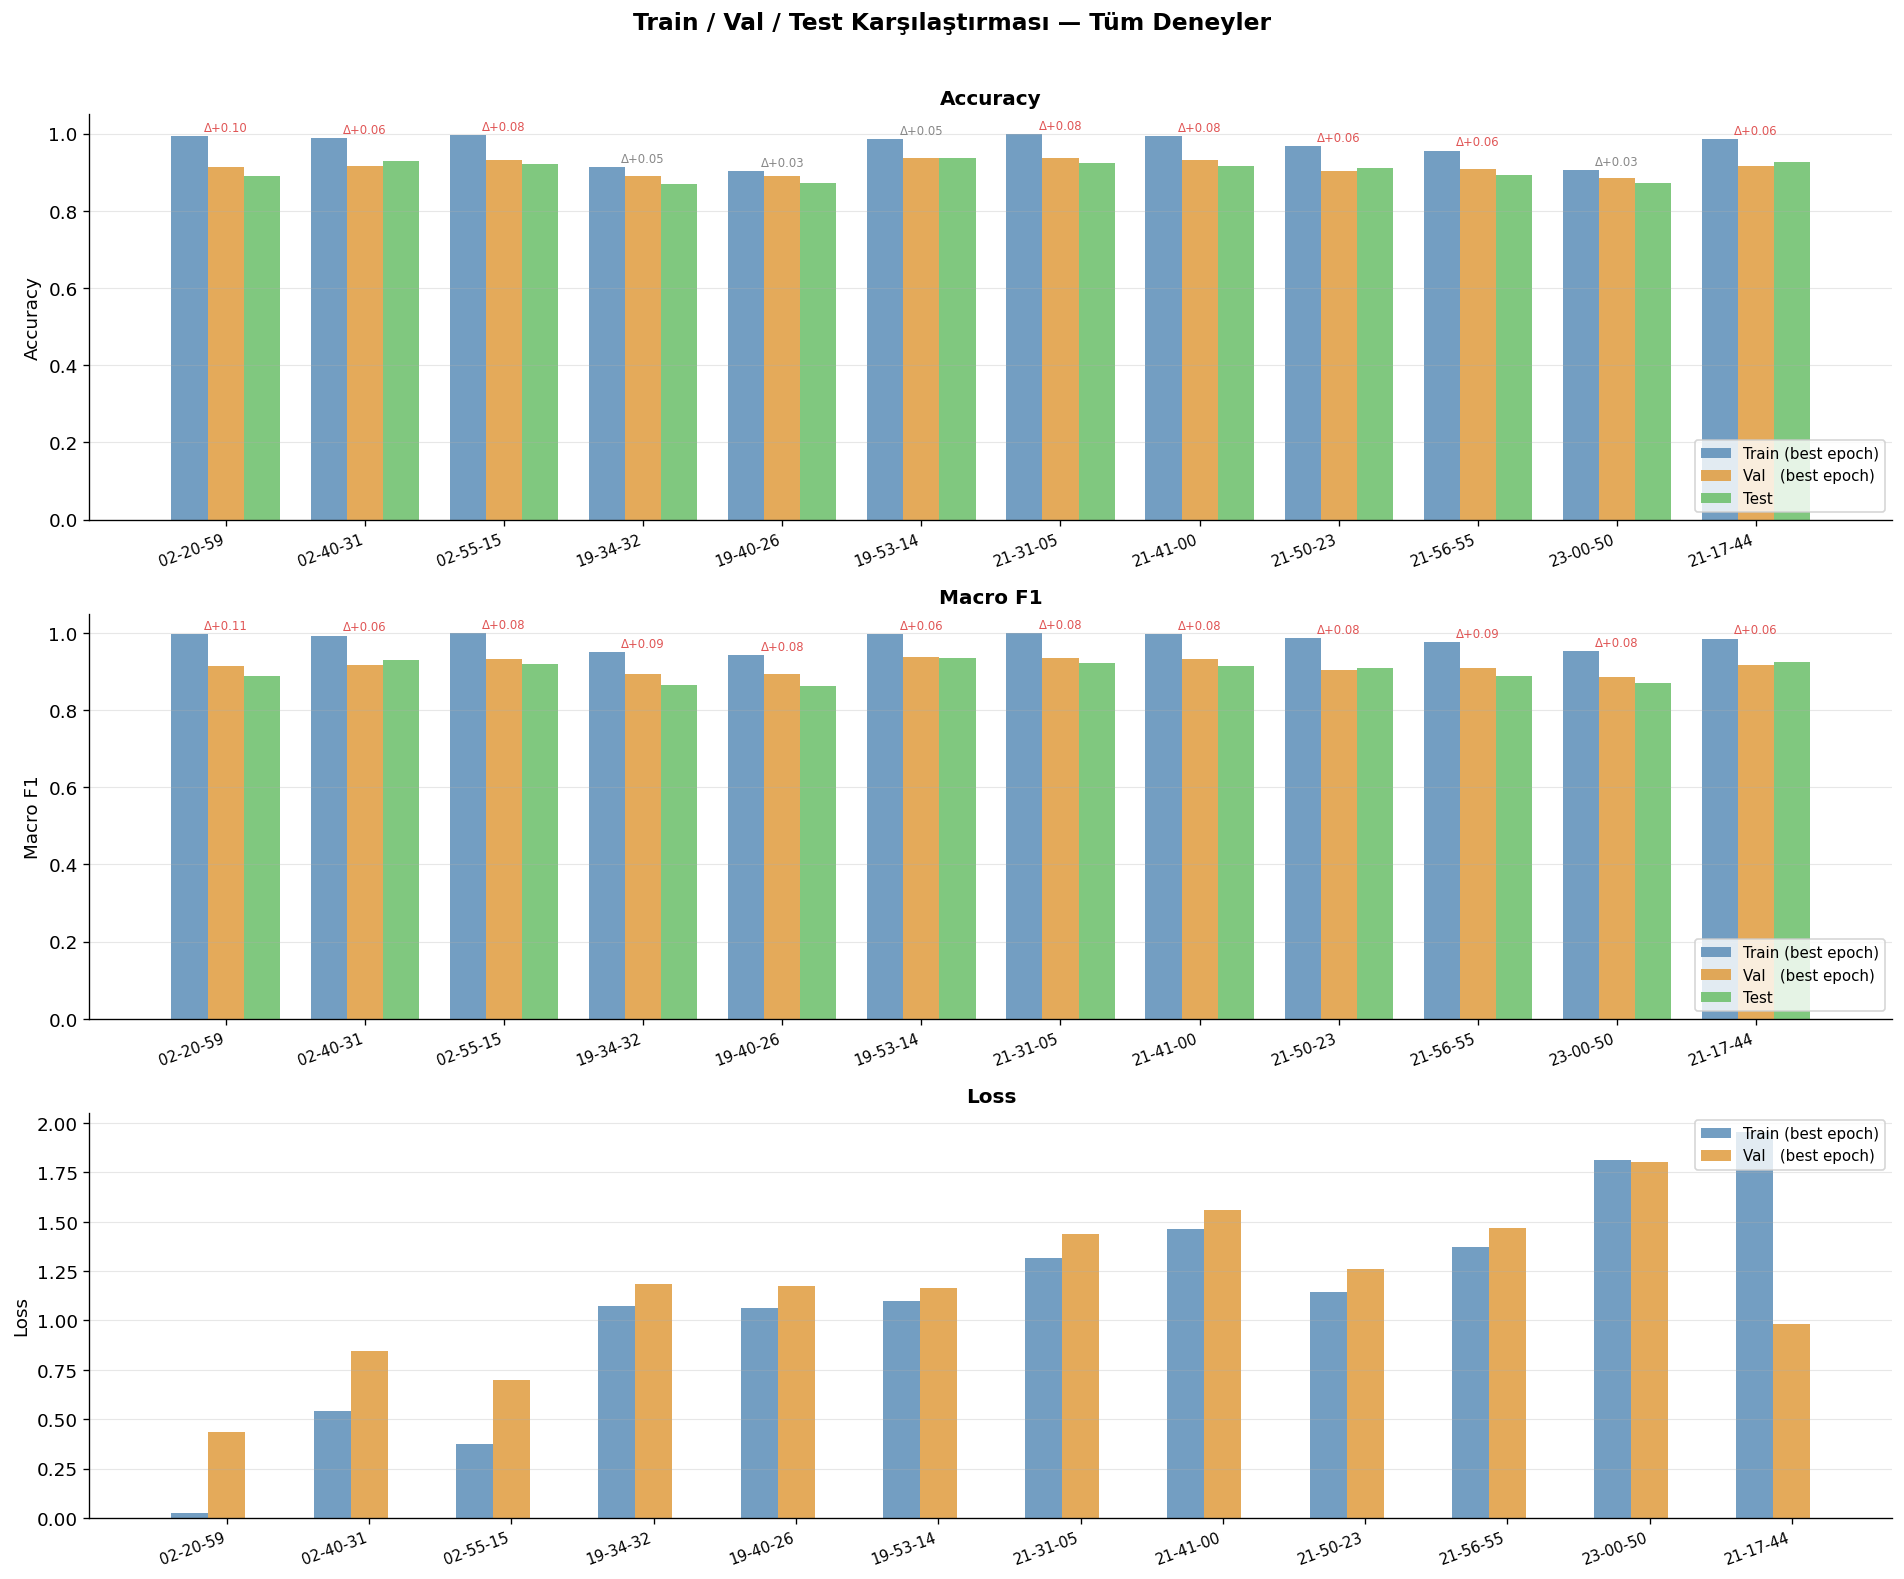

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Her deney için best epoch train metriklerini çek
records = []
for exp in experiments:
    name  = exp['name'][11:]  # HH-MM-SS
    te    = exp['test_metrics']
    tm    = exp['train_metrics']

    test_acc = te.get('accuracy', np.nan)
    test_f1  = te.get('macro_f1', np.nan)

    if tm:
        val_accs  = [e.get('val', {}).get('accuracy', 0) for e in tm]
        best_i    = int(np.argmax(val_accs))
        train_acc  = tm[best_i].get('train', {}).get('accuracy', np.nan)
        train_f1   = tm[best_i].get('train', {}).get('macro_f1', np.nan)
        train_loss = tm[best_i].get('train', {}).get('loss', np.nan)
        val_loss   = tm[best_i].get('val',   {}).get('loss', np.nan)
        val_acc    = tm[best_i].get('val',   {}).get('accuracy', np.nan)
        val_f1     = tm[best_i].get('val',   {}).get('macro_f1', np.nan)
    else:
        train_acc = train_f1 = train_loss = val_loss = val_acc = val_f1 = np.nan

    records.append({
        'name':       name,
        'train_acc':  train_acc,
        'val_acc':    val_acc,
        'test_acc':   test_acc,
        'train_f1':   train_f1,
        'val_f1':     val_f1,
        'test_f1':    test_f1,
        'train_loss': train_loss,
        'val_loss':   val_loss,
    })

labels = [r['name'] for r in records]
x      = np.arange(len(labels))
w      = 0.26  # bar genişliği

fig, axes = plt.subplots(3, 1, figsize=(16, 13))
fig.suptitle('Train / Val / Test Karşılaştırması — Tüm Deneyler', fontsize=14, fontweight='bold', y=1.01)

COLORS = {'train': '#5b8db8', 'val': '#e09b3d', 'test': '#6abf69'}

for ax, metric, title in [
    (axes[0], 'acc',  'Accuracy'),
    (axes[1], 'f1',   'Macro F1'),
    (axes[2], 'loss', 'Loss'),
]:
    tr_vals   = [r[f'train_{metric}'] for r in records]
    val_vals  = [r[f'val_{metric}']   for r in records]

    ax.bar(x - w, tr_vals,  width=w, label='Train (best epoch)', color=COLORS['train'], alpha=0.85)
    ax.bar(x,     val_vals, width=w, label='Val   (best epoch)', color=COLORS['val'],   alpha=0.85)

    if metric != 'loss':
        te_vals = [r[f'test_{metric}'] for r in records]
        ax.bar(x + w, te_vals, width=w, label='Test', color=COLORS['test'], alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9, rotation=20, ha='right')
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, loc='lower right' if metric != 'loss' else 'upper right')
    ax.grid(axis='y', alpha=0.3, linewidth=0.7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Gap annotation (train - test farkı, overfitting göstergesi)
    if metric != 'loss':
        for i, (tr, te) in enumerate(zip(tr_vals, te_vals)):
            if not (np.isnan(tr) or np.isnan(te)):
                gap = tr - te
                color = '#e05555' if gap > 0.05 else '#888888'
                ax.text(i, max(tr, te) + 0.005, f'Δ{gap:+.2f}',
                        ha='center', va='bottom', fontsize=7, color=color)

plt.tight_layout()
plt.show()

## 6. Sınıf Bazlı Performans
Her sınıf (kelime) için F1 skoru — deneyler arası karşılaştırma.


In [33]:
def extract_per_class(exp):
    """per_class_raw -> {class_name: f1} dict"""
    pc = exp.get('per_class_raw', {})
    return {cls: vals.get('f1', None) for cls, vals in pc.items()}

per_class_dfs = {}
for exp in experiments:
    pc = extract_per_class(exp)
    if pc:
        per_class_dfs[exp['name']] = pc

if per_class_dfs:
    df_pc = pd.DataFrame(per_class_dfs)
    df_pc['mean_f1'] = df_pc.mean(axis=1)
    df_pc = df_pc.sort_values('mean_f1')
    df_pc = df_pc.drop(columns='mean_f1')
    print('Sınıf bazlı F1 tablosu (düşükten yükseğe):')
    display(df_pc.style
            .background_gradient(cmap='RdYlGn', axis=1, vmin=0, vmax=1)
            .format('{:.3f}', na_rep='-')
            .set_caption('Sınıf Bazlı F1 Skorları'))
else:
    print('per_class verisi bulunamadı.')

Sınıf bazlı F1 tablosu (düşükten yükseğe):


,2026-05-23_02-20-59,2026-05-23_02-40-31,2026-05-23_02-55-15,2026-05-23_19-34-32,2026-05-23_19-40-26,2026-05-23_19-53-14,2026-05-23_21-31-05,2026-05-23_21-41-00,2026-05-23_21-50-23,2026-05-23_21-56-55,2026-05-23_23-00-50,2026-05-26_21-17-44
5_evet,0.621,0.759,0.741,0.643,0.606,0.786,0.733,0.640,0.560,0.828,0.593,0.710
16_nerede,0.690,0.875,0.800,0.444,0.333,0.875,0.903,0.867,0.778,0.667,0.588,0.788
25_zaman,0.625,0.848,0.733,0.688,0.462,0.824,0.824,0.688,0.647,0.759,0.667,0.903
7_tesekkur,0.733,0.909,0.903,0.652,0.682,0.875,0.833,0.774,0.909,0.640,0.645,0.741
27_yemek,0.774,0.848,0.774,0.774,0.786,0.786,0.867,0.741,0.872,0.640,0.774,0.800
12_iyi,0.741,0.846,0.815,0.800,0.889,0.812,0.867,0.889,0.800,0.727,0.667,0.933
18_doktor,0.829,0.895,0.791,0.829,0.810,0.872,0.829,0.773,0.773,0.829,0.872,0.872
0_ben,0.857,0.857,0.857,0.857,0.769,0.897,0.815,0.857,0.857,0.857,0.848,0.857
6_hayir,0.872,0.821,0.842,0.865,0.842,0.919,0.919,0.872,0.882,0.780,0.848,0.833
23_ataturk,0.889,0.865,0.970,0.759,0.833,0.933,0.875,0.897,0.941,0.857,0.789,1.000


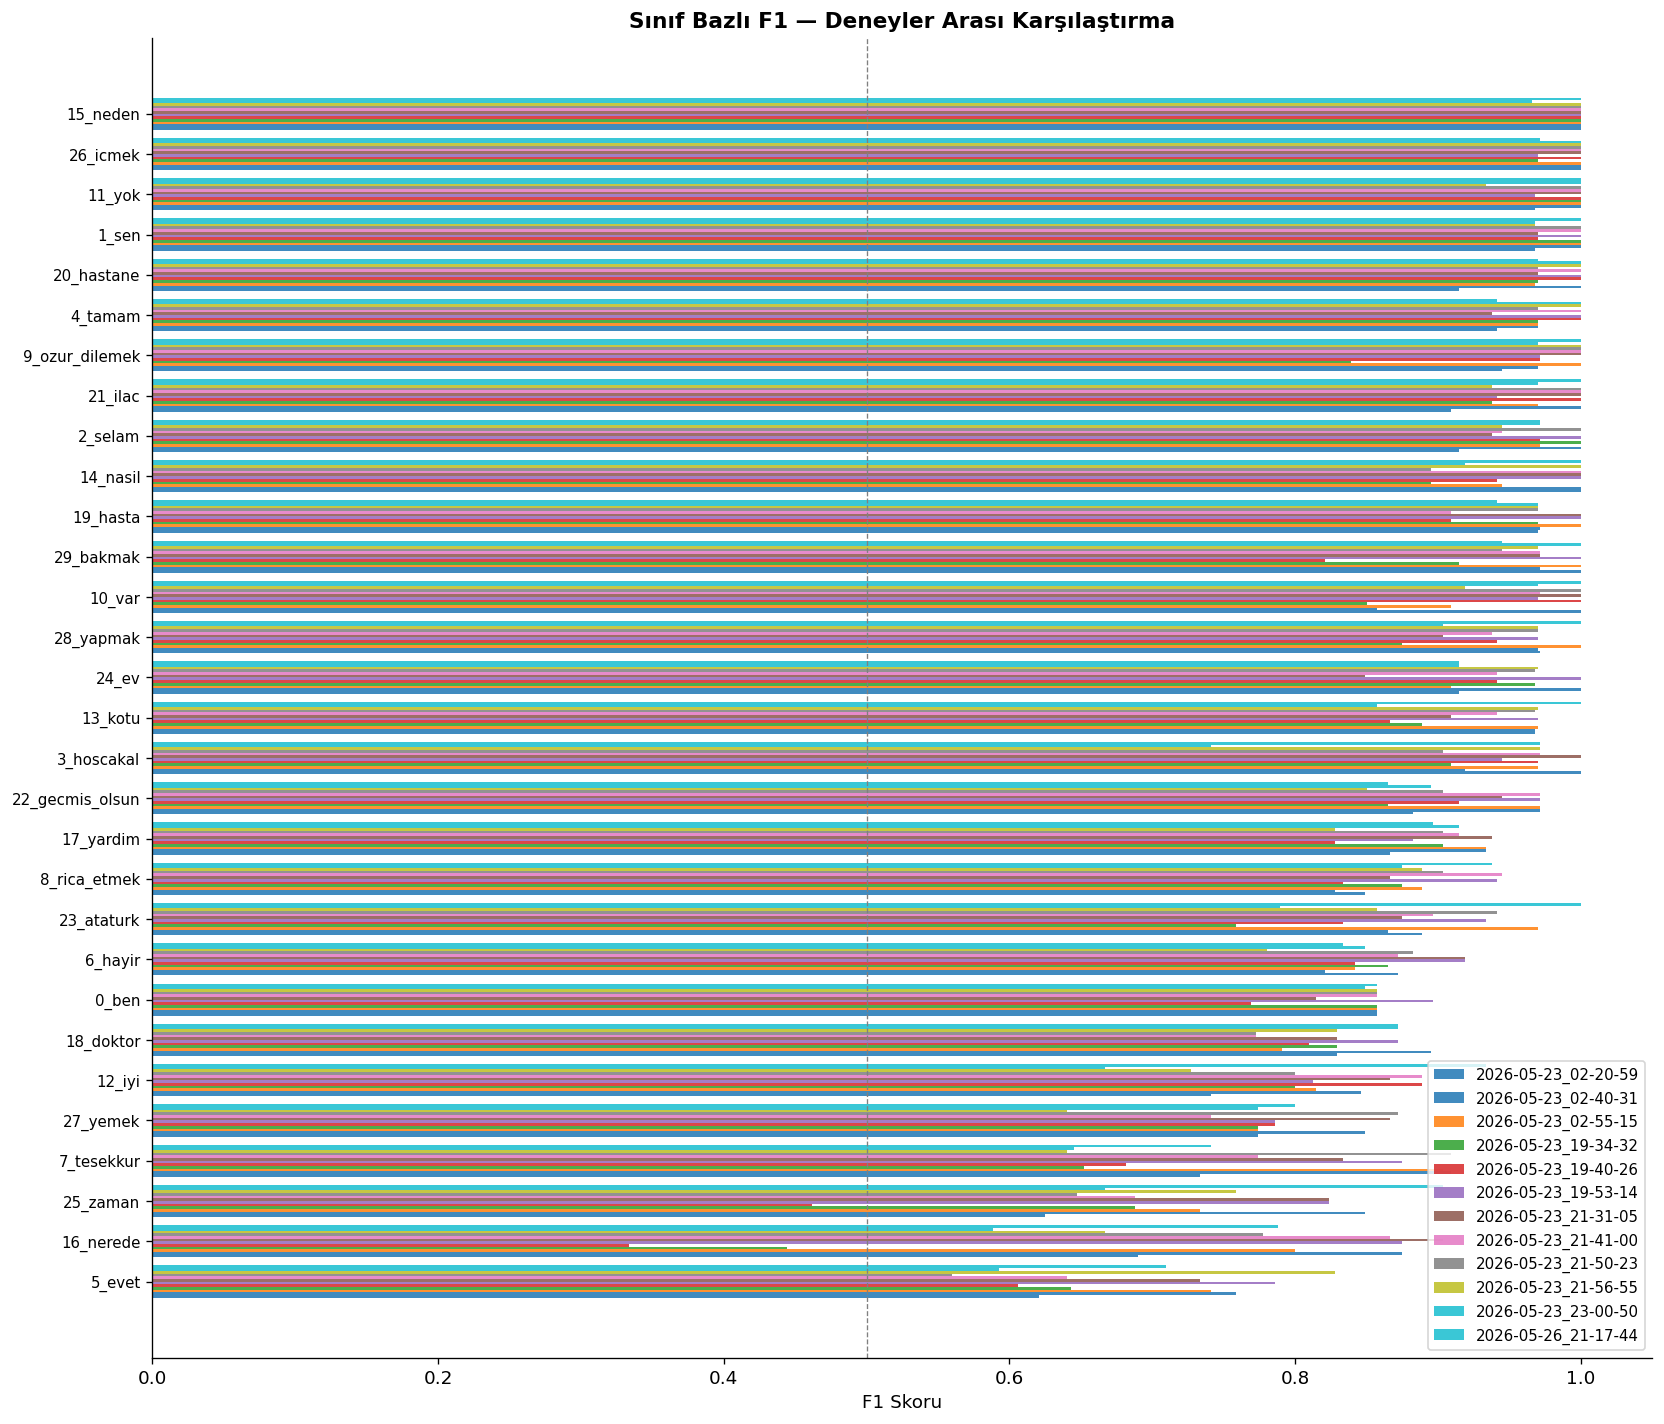

In [34]:
if per_class_dfs:
    n_classes = len(df_pc)
    fig, ax = plt.subplots(figsize=(14, max(6, n_classes * 0.4)))

    y_pos = np.arange(n_classes)
    bar_h = 0.8 / max(len(per_class_dfs), 1)
    colors = plt.cm.tab10(np.linspace(0, 1, len(per_class_dfs)))

    for i, (exp_name, color) in enumerate(zip(per_class_dfs.keys(), colors)):
        vals = [df_pc.loc[cls, exp_name] if cls in df_pc.index else 0
                for cls in df_pc.index]
        offset = (i - len(per_class_dfs) / 2 + 0.5) * bar_h
        ax.barh(y_pos + offset, vals, height=bar_h,
                label=exp_name, color=color, alpha=0.85)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(df_pc.index, fontsize=9)
    ax.set_xlabel('F1 Skoru')
    ax.set_title('Sınıf Bazlı F1 — Deneyler Arası Karşılaştırma', fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.axvline(0.5, color='gray', linestyle='--', linewidth=0.8)
    ax.set_xlim(0, 1.05)
    plt.tight_layout()
    plt.show()


In [35]:
# En zorlanan sınıflar (tøm deneylerde ortalama F1 en düş¸k olanlar)
if per_class_dfs:
    mean_f1 = df_pc.mean(axis=1).sort_values()
    print('En zorlanan 5 sınıf (ortalama F1):')
    for cls, f1 in mean_f1.head(5).items():
        print(f'  {cls:25s}  F1 = {f1:.4f}')
    print()
    print('En başarılı 5 sınıf (ortalama F1):')
    for cls, f1 in mean_f1.tail(5).items():
        print(f'  {cls:25s}  F1 = {f1:.4f}')


En zorlanan 5 sınıf (ortalama F1):
  5_evet                     F1 = 0.6848
  16_nerede                  F1 = 0.7173
  25_zaman                   F1 = 0.7222
  7_tesekkur                 F1 = 0.7748
  27_yemek                   F1 = 0.7863

En başarılı 5 sınıf (ortalama F1):
  20_hastane                 F1 = 0.9801
  1_sen                      F1 = 0.9869
  11_yok                     F1 = 0.9891
  26_icmek                   F1 = 0.9926
  15_neden                   F1 = 0.9971


## 7. Confusion Matrix Karşılaştırması
Her deneyin `confusion_matrix.png` dosyası yan yana gösterilir.


In [36]:
import matplotlib.image as mpimg

cm_experiments = [e for e in experiments if e['cm_path']]

if not cm_experiments:
    print('Hicbir deneyde confusion_matrix.png bulunamadi.')
else:
    n = len(cm_experiments)
    cols = min(n, 2)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 9, rows * 8))
    axes = np.array(axes).reshape(-1)

    for i, exp in enumerate(cm_experiments):
        img = mpimg.imread(exp['cm_path'])
        axes[i].imshow(img)
        axes[i].set_title(exp['name'], fontsize=10, fontweight='bold')
        axes[i].axis('off')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()


Output hidden; open in https://colab.research.google.com to view.